In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import pandas as pd
import seaborn as sns

In [2]:
# to get the different test sets
config_fp = '../experiment_configs/train_baseline_local_models.yaml'
cfg_hp_search = read_config_file(config_fp)
cfg_data = cfg_hp_search['data']
split_seed = cfg_data['split_seed']

resolution=10

In [3]:
project_dir = '..' #get_project_dir()
lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_10m'
lidar_1m_dir = f'/n/tambe_lab/Everyone/data_mar8/raw/lidar_by_site_32736'

outputs_dir = '/n/tambe_lab/Everyone/tree_mapping/model_output'

reference_maps = ['ETH', 'GLAD', 'META', 'PAULS']
#models = [f'local_only_models/128_filters/{x}' for x in ['3_channels', '4_channels', '12_channels', '15_channels']]
models = [f'local_only_models/128_filters/{x}' for x in ['12_channels']]

#pred padding is defined by how we cropped the satellite imagery to Karingani sites
pred_padding = 40

eval_metric = 'rmse'

sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])

# calculate AGB estimates with linear formula

In [4]:
def estimate_AGB(tch_values_in, nodata_value=-9999.):
    # estimate above ground biomass using formulas and from Colgan et al. 2013
    # https://esajournals.onlinelibrary.wiley.com/doi/abs/10.1890/12-0922.
    cc_cutoff = 1.5 # meters
    h_cutoff = 0.0
    b_0 = -7.15
    b_1 = 23.2
    
    tch_values = tch_values_in.copy()
    tch_values = tch_values_in[tch_values_in != nodata_value]
    
    if (tch_values == 0).all(): return 0,0

    CC = np.mean(tch_values >= cc_cutoff)
    H = np.mean(tch_values[tch_values > h_cutoff])
    X = H * CC
    
    return X * b_1 + b_0, X

In [5]:
model = 'local_only_models/128_filters/12_channels/12_train_sites/seed_0'
model_output_dir = f'{outputs_dir}/{model}'
existing_maps_dir = f'../../tree_mapping/data/existing_reference_data'
model_output_dir_1m = f'/n/tambe_lab/Everyone/tree_mapping/model_output_1m/{model}'

In [6]:
num_splits = 4
sites_by_split = {x:[] for x in np.arange(num_splits)}
AGB_from_labels_by_split = {x:[] for x in np.arange(num_splits)}
X_from_labels_by_split = {x:[] for x in np.arange(num_splits)}

AGB_estimated_by_preds_by_split = {}
X_estimated_by_preds_by_split = {}
for key in reference_maps + ['ours',]:
    AGB_estimated_by_preds_by_split[key] = {x:[] for x in np.arange(num_splits)}
    X_estimated_by_preds_by_split[key] = {x:[] for x in np.arange(num_splits)}

data_dir = '../data'
nodata_value = -9999.

for split_number in range(4):
    print('split', split_number)
    test_sites = get_site_splits(split_seed, data_dir = data_dir)[split_number]['test_sites']   
    sites_by_split[split_number] = test_sites
    
    for site in test_sites:
        with rasterio.open(f'{lidar_1m_dir}/{site}_CHM_{1}m_merged.tif') as file: # opens label tiff
            site_labels_1m = file.read().ravel()
            print(site_labels_1m[site_labels_1m != -9999.].min(), site_labels_1m[site_labels_1m != -9999.].max())    
        with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_10m.tif') as file: # opens label tiff
            site_labels_10m = file.read().ravel()
         #   print(site_labels[site_labels != -9999.].min(), site_labels[site_labels != -9999.].max())    
            
        AGB_estimated_by_labels, X_labels = estimate_AGB(site_labels_1m, nodata_value=-9999.)
        
        AGB_from_labels_by_split[split_number].append(AGB_estimated_by_labels)
        X_from_labels_by_split[split_number].append(X_labels)
        
        for map_type, map_fn in [('META', f'{existing_maps_dir}/meta_maps_per_site_1m/META_MAP_{site}_1m.tif'),
                                ('ours', f'{model_output_dir}/preds_{site}.tif'),
                                 ('GLAD', f'{existing_maps_dir}/glad_maps_per_site_10m/GLAD_MAP_{site}_10m.tif'),
                                 ('ETH', f'{existing_maps_dir}/eth_maps_per_site_10m/ETH_MAP_{site}_10m.tif'),
                                 ('PAULS', f'{existing_maps_dir}/pauls_maps_per_site_10m/PAULS_MAP_{site}_10m.tif'),
                                ]:
        
            with rasterio.open(map_fn) as file: # opens prediction tiff
                if map_type == 'ours':
                    buffer = 40
                    site_preds = file.read()[0,buffer:-buffer,buffer:-buffer].ravel()
                else:
                    site_preds = file.read().ravel()
            
            if map_type == 'META': nodata_labels_mask = site_preds[site_labels_1m != -9999.]
            else: nodata_labels_mask = site_preds[site_labels_10m != -9999.]
            AGB_estimated, X = estimate_AGB(nodata_labels_mask, nodata_value=-9999.)
            AGB_estimated_by_preds_by_split[map_type][split_number].append(AGB_estimated)
            X_estimated_by_preds_by_split[map_type][split_number].append(X)


split 0
0.0 15.656
0.0 18.4
0.0 18.598
0.0 18.516
0.0 17.623
0.0 19.658
split 1
0.0 23.319
0.0 28.381
0.0 22.207
0.0 16.42
0.0 17.927
0.0 17.871
split 2
0.0 17.036
0.0 19.646
0.0 28.868
0.0 17.878
0.0 18.341
0.0 29.918
split 3
0.0 26.666
0.0 17.475
0.0 19.844
0.0 19.85
0.0 15.839
0.0 16.635


In [7]:
# # AGB_labels = np.hstack([AGB_from_labels_by_split[j] for j in range(4)])
# # X_preds_ours = np.hstack([X_estimated_by_preds_by_split['ours'][j] for j in range(4)])
# # X_preds_meta = np.hstack([X_estimated_by_preds_by_split['META'][j] for j in range(4)])

# AGB_labels = np.hstack([AGB_from_labels_by_split[i] for i in range(4)])
# AGB_preds_meta = np.hstack([AGB_estimated_by_preds_by_split['META'][i] for i in range(4)])
# AGB_preds_ours = np.hstack([AGB_estimated_by_preds_by_split['ours'][i] for i in range(4)])
# X_preds_meta = np.hstack([X_estimated_by_preds_by_split['META'][i] for i in range(4)])
# X_preds_ours = np.hstack([X_estimated_by_preds_by_split['ours'][i] for i in range(4)])

# b0_ours, b1_ours = np.polyfit(X_preds_ours, AGB_labels, 1)
# rmse_fit_ours = np.sqrt(np.mean((X_preds_ours * b0_ours + b1_ours - AGB_labels) **2))

# b0_meta, b1_meta = np.polyfit(X_preds_meta, AGB_labels, 1)
# rmse_fit_meta = np.sqrt(np.mean((X_preds_meta * b0_meta + b1_meta - AGB_labels) **2))

# AGB_labels = np.hstack([AGB_from_labels_by_split[i] for i in range(4)])
# AGB_preds_meta = np.hstack([AGB_estimated_by_preds_by_split['META'][i] for i in range(4)])
# AGB_preds_ours = np.hstack([AGB_estimated_by_preds_by_split['ours'][i] for i in range(4)])
# X_preds_meta = np.hstack([X_estimated_by_preds_by_split['META'][i] for i in range(4)])
# X_preds_ours = np.hstack([X_estimated_by_preds_by_split['ours'][i] for i in range(4)])

# fig, ax = plt.subplots()
# plt.scatter([],[])
# plt.scatter([],[])
# plt.scatter(AGB_preds_ours, AGB_labels, label = 'ours')
# plt.scatter([],[])
# plt.scatter(AGB_preds_meta, AGB_labels, label='meta')
# plt.xlabel('estimated using predicted maps (@1m for meta, @10m for ours)')
# plt.ylabel('ABG from 1m lidar-derived CHM (kg)')

# plt.legend()
# plt.plot([0,60],[0,60], color='black', ls= '--', label = 'y = x')
# plt.title('estimated ABG using coefficients from Colgan et al. 2013')

In [8]:
AGB_labels = np.hstack([AGB_from_labels_by_split[j] for j in range(4)])
X_preds_ours = np.hstack([X_estimated_by_preds_by_split['ours'][j] for j in range(4)])
X_preds_meta = np.hstack([X_estimated_by_preds_by_split['META'][j] for j in range(4)])

model_types = ['GLAD', 'ETH', 'META', 'PAULS', 'ours']
titles = ['GLAD (30m resolution)', 'ETH (10m resolution)', 'Meta (1m resolution)', 'Pauls et al. (10m resolution)', 'Local FCN (ours, 10m resolution)']

#colors 
#colors = [sns.color_palette()[x] for x in [0,1,4,2]]

colors_dict = {'ETH':sns.color_palette()[0],
                    'GLAD':sns.color_palette()[1],
                    'META':sns.color_palette()[4],
                    'PAULS':sns.color_palette()[5],
                   'ours': sns.color_palette()[2]
              }

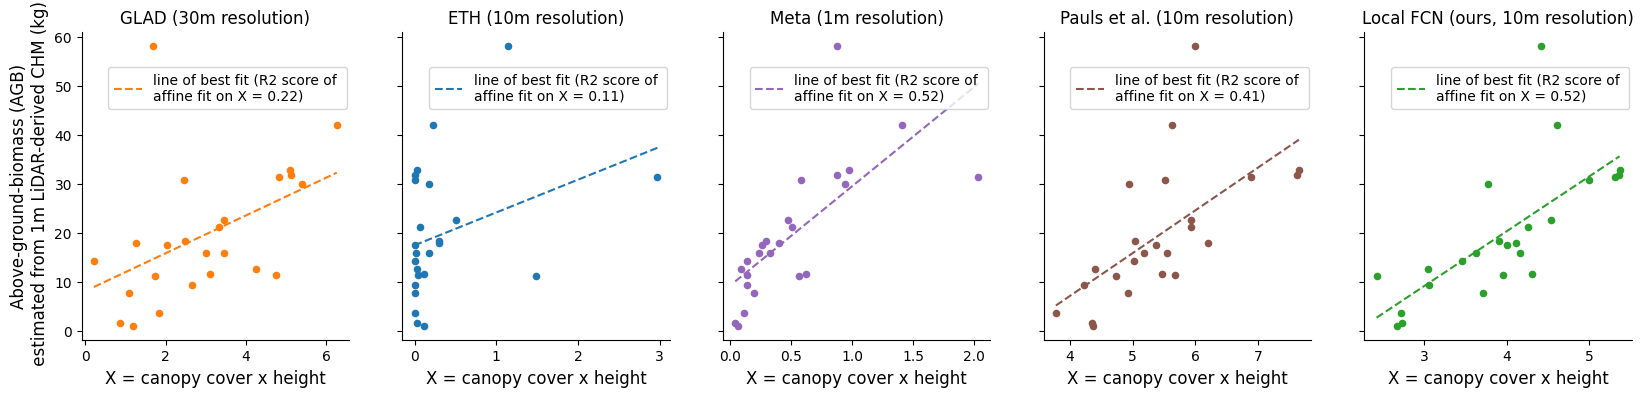

In [9]:
fig, ax = plt.subplots(1,5, figsize=(20,4), sharey=True)
for i,ax_this in enumerate(ax):
    model_type = model_types[i]
    X_preds= np.hstack([X_estimated_by_preds_by_split[model_type][j] for j in range(4)])
 
    b0, b1 = np.polyfit(X_preds, AGB_labels, 1)
    rmse_fit = np.sqrt(np.mean((X_preds * b0 + b1 - AGB_labels) **2))
    r2_score = sklearn.metrics.r2_score(AGB_labels, X_preds * b0 + b1)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(AGB_labels, X_preds * b0 + b1))
    
    ax_this.scatter(X_preds, AGB_labels, color=colors_dict[model_type], s=20)
    ax_this.plot([X_preds.min(),X_preds.max()],
         [X_preds.min()*b0 +b1,X_preds.max()*b0 +b1],  
                 color=colors_dict[model_type],
                 #\nroot MSE = {rmse_fit:.1f}
         ls= '--', label = f'line of best fit' 
               #  + f'\n(RMSE of linear fit = {rmse:.2f})'
                 + f' (R2 score of \naffine fit on X = {r2_score:.2f})')
    ax_this.legend(loc=(.1,.75), fontsize=10)
    ax_this.set_title(titles[i])

# ax[1].scatter(X_preds_ours, AGB_labels)
# ax[1].plot([X_preds_ours.min(),X_preds_ours.max()],
#          [X_preds_ours.min()*b0_ours + b1_ours, X_preds_ours.max()*b0_ours + b1_ours],  
#          ls= '--', label = f'line of best fit (ours)\nroot MSE = {rmse_fit_ours:.1f} ')

for ax_this in ax:
    ax_this.set_xlabel('X = canopy cover x height', fontsize='large')
    
ax[0].set_ylabel('Above-ground-biomass (AGB)\n estimated from 1m LiDAR-derived CHM (kg)', fontsize='large')
sns.despine()
plt.savefig('../figures/agb_comparison.png', bbox_inches='tight')

In [10]:
# this one shows the rescaled predictions (affine fit on X):

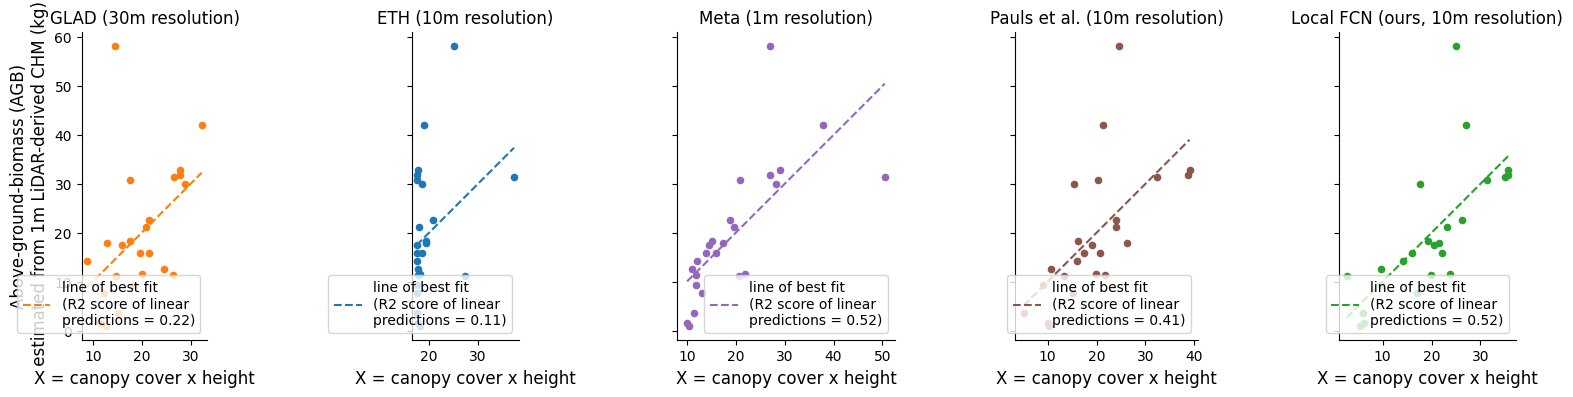

In [11]:

fig, ax = plt.subplots(1,5, figsize=(20,4), sharey=True)#, aspect='equal')
for i,ax_this in enumerate(ax):
    model_type = model_types[i]
    X_preds= np.hstack([X_estimated_by_preds_by_split[model_type][j] for j in range(4)])
 
    b0, b1 = np.polyfit(X_preds, AGB_labels, 1)
    rmse_fit = np.sqrt(np.mean((X_preds * b0 + b1 - AGB_labels) **2))
    r2_score = sklearn.metrics.r2_score(AGB_labels, X_preds * b0 + b1)
    
    ax_this.scatter(X_preds * b0 + b1, AGB_labels, color=colors_dict[model_type], s=20)
    ax_this.plot([X_preds.min()*b0 +b1,X_preds.max()*b0 +b1],
         [X_preds.min()*b0 +b1,X_preds.max()*b0 +b1],  
                 color=colors_dict[model_type],
                 #\nroot MSE = {rmse_fit:.1f}
         ls= '--', label = f'line of best fit' + f'\n(R2 score of linear \npredictions = {r2_score:.2f})')
    ax_this.legend(loc='lower right', fontsize=10)
    ax_this.set_title(titles[i])
    ax_this.set_aspect('equal')
# ax[1].scatter(X_preds_ours, AGB_labels)
# ax[1].plot([X_preds_ours.min(),X_preds_ours.max()],
#          [X_preds_ours.min()*b0_ours + b1_ours, X_preds_ours.max()*b0_ours + b1_ours],  
#          ls= '--', label = f'line of best fit (ours)\nroot MSE = {rmse_fit_ours:.1f} ')

for ax_this in ax:
    ax_this.set_xlabel('X = canopy cover x height', fontsize='large')
    
ax[0].set_ylabel('Above-ground-biomass (AGB)\n estimated from 1m LiDAR-derived CHM (kg)', fontsize='large')
sns.despine()
